# 11 - Ingest Documentation with Gemini and Pinecone

This notebook continues the instructor's `ingestion.py` flow.

```text
Saved LangChain Documents
→ RecursiveCharacterTextSplitter(4000, 200)
→ Gemini embeddings
→ PineconeVectorStore
→ asynchronous batched indexing
```

Changes from the instructor are limited to:

- Gemini embeddings instead of OpenAI embeddings
- Pinecone as the active vector store
- Loading documents saved by notebook 10

## 1. Optional installation

In [ ]:
# %pip install -U langchain-google-genai langchain-pinecone langchain-text-splitters pinecone python-dotenv truststore

## 2. SSL, imports, and environment variables

In [6]:
import truststore
truststore.inject_into_ssl()

from pathlib import Path
ENV_PATH = Path("../langchain-course/.env").resolve()

from dotenv import load_dotenv
load_dotenv(dotenv_path=ENV_PATH)

import asyncio
import json
import os

from langchain_core.documents import Document
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from langchain_pinecone import PineconeVectorStore
from pinecone import Pinecone
from langchain_text_splitters import RecursiveCharacterTextSplitter

## 3. Configuration

In [7]:
INDEX_NAME = os.environ["DOCUMENTATION_INDEX_NAME"]
NAMESPACE = "langchain-docs"
INPUT_FILE = Path("langchain_docs.json")

EMBEDDING_MODEL = "gemini-embedding-001"
EMBEDDING_DIMENSION = 1536


## 4. Load the documents created in notebook 10

In [8]:
saved_documents = json.loads(
    INPUT_FILE.read_text(encoding="utf-8")
)

documents = [
    Document(
        page_content=item["page_content"],
        metadata=item["metadata"],
    )
    for item in saved_documents
]

print("Documents loaded:", len(documents))


Documents loaded: 40


## 5. Initialize Gemini embeddings and Pinecone

The embedding dimensionality matches the Pinecone index created earlier.

In [9]:
embeddings = GoogleGenerativeAIEmbeddings(
    model=EMBEDDING_MODEL,
    google_api_key=os.environ["GOOGLE_API_KEY"],
    output_dimensionality=EMBEDDING_DIMENSION,
)

vectorstore = PineconeVectorStore(
    index_name=INDEX_NAME,
    embedding=embeddings,
    namespace=NAMESPACE,
)


## 6. Split the documentation

This matches the instructor's splitter configuration.

In [10]:
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=4000,
    chunk_overlap=200,
)

chunks = text_splitter.split_documents(documents)

print("Source documents:", len(documents))
print("Chunks created:", len(chunks))


Source documents: 40
Chunks created: 141


## 7. Asynchronous batch indexing

This follows the instructor's structure: create batches, create one asynchronous task per batch, and execute the tasks with `asyncio.gather()`.

Gemini free-tier limits are lower than the instructor's OpenAI setup. Use a smaller batch size if Gemini returns `429 RESOURCE_EXHAUSTED`.

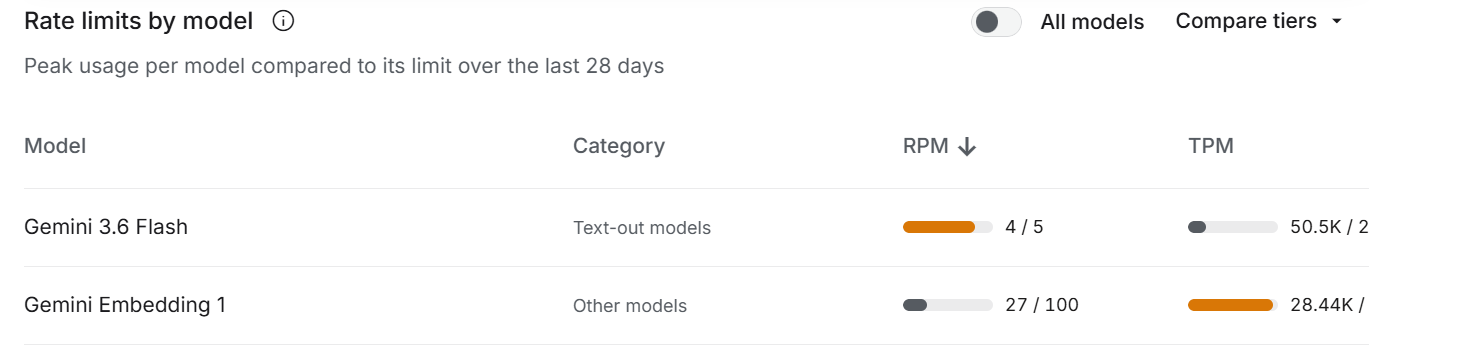

In [11]:
async def index_documents_async(
    documents: list[Document],
    batch_size: int = 10,
    wait_seconds: int = 65,
    max_concurrent_batches: int = 1,
):
    """
    Split documents into batches and upload them asynchronously.

    Asyncio overview
    ----------------
    `asyncio` allows Python to manage multiple waiting operations
    cooperatively within one thread.

    An async function is declared with:

        async def

    Calling an async function creates a coroutine. The coroutine runs
    when it is awaited:

        results = await index_documents_async(...)

    During an awaited network request or an asynchronous sleep, Python
    can temporarily switch to another eligible task instead of blocking
    the entire program.

    Important asyncio components used here
    ---------------------------------------
    1. Coroutine:
       `add_batch()` is an async function. Each call creates a coroutine
       representing the work required to upload one batch.

    2. Semaphore:
       `asyncio.Semaphore(max_concurrent_batches)` limits how many batch
       coroutines may access Gemini and Pinecone simultaneously.

       For example:

           max_concurrent_batches = 1
           → Only one batch runs at a time.

           max_concurrent_batches = 2
           → Up to two batches can run at the same time.

    3. Await:
       `await` pauses the current coroutine until an asynchronous
       operation completes. The event loop can run another eligible
       coroutine during that waiting period.

    4. asyncio.gather:
       `asyncio.gather()` schedules all batch coroutines and waits until
       every batch finishes. The semaphore still controls how many of
       those scheduled tasks may perform an upload simultaneously.

    5. asyncio.sleep:
       Unlike `time.sleep()`, `asyncio.sleep()` does not block the
       event loop. It pauses the current batch coroutine while allowing
       other eligible tasks to run.

    Parameters
    ----------
    documents:
        LangChain Document chunks to embed and upload.

    batch_size:
        Number of document chunks included in each batch.

    wait_seconds:
        Number of seconds to wait after a successful batch. This gives
        the rolling Gemini tokens-per-minute quota time to recover.

    max_concurrent_batches:
        Maximum number of batches allowed to call Gemini and Pinecone
        simultaneously.

        Use 1 for the current Gemini free-tier embedding limits.
        Increase this value only when the paid-tier RPM and TPM limits
        can support parallel batches.

    Returns
    -------
    list:
        One result for every batch:

        - True if the batch succeeded
        - False if the batch failed
        - An exception object if an unexpected exception escaped from
          a coroutine and `return_exceptions=True` captured it
    """

    print("=" * 72)
    print("VECTOR STORAGE PHASE")
    print("=" * 72)

    # Divide the complete list of document chunks into smaller batches.
    #
    # Example:
    # 25 documents with batch_size=10
    # → batch 1 contains documents 0-9
    # → batch 2 contains documents 10-19
    # → batch 3 contains documents 20-24
    batches = [
        documents[i:i + batch_size]
        for i in range(
            0,
            len(documents),
            batch_size,
        )
    ]

    print(
        f"Preparing to add {len(documents)} chunks "
        f"across {len(batches)} batches."
    )

    # A semaphore controls how many batch coroutines may enter the
    # upload section at the same time.
    #
    # Semaphore(1):
    # Only one batch may call Gemini and Pinecone at a time.
    #
    # Semaphore(2):
    # Up to two batches may call Gemini and Pinecone simultaneously.
    #
    # All batch tasks are still created below, but tasks that cannot
    # acquire the semaphore wait until a permit becomes available.

    semaphore = asyncio.Semaphore(
        max_concurrent_batches
    )

    async def add_batch(
        batch,
        batch_number,
    ):
        """
        Upload one batch of document chunks.

        This nested async function is converted into one coroutine for
        every batch. The semaphore controls when each coroutine is
        allowed to perform the upload.
        """

        # Wait asynchronously until a semaphore permit is available.
        #
        # When max_concurrent_batches=1, only one add_batch coroutine
        # can execute inside this block at a time.
        async with semaphore:
            try:
                print(
                    f"Processing batch "
                    f"{batch_number}/{len(batches)}..."
                )

                # `aadd_documents()` is the asynchronous version of
                # `add_documents()`.
                #
                # Internally, the operation:
                # 1. Sends chunk text to Gemini for embedding.
                # 2. Receives the embedding vectors.
                # 3. Sends the vectors and metadata to Pinecone.
                #
                # `await` pauses this batch coroutine until the network
                # operation completes. The event loop may run another
                # eligible coroutine during this waiting period.
                await vectorstore.aadd_documents(
                    batch
                )

                print(
                    f"Batch {batch_number}/"
                    f"{len(batches)} "
                    f"uploaded successfully."
                )

                # Wait for the rolling Gemini tokens-per-minute quota
                # to recover before releasing the semaphore permit.
                #
                # The condition avoids an unnecessary wait after the
                # final numbered batch.
                if batch_number < len(batches):
                    print(
                        f"Waiting {wait_seconds} seconds "
                        f"before the next batch."
                    )

                    # Use asyncio.sleep(), not time.sleep().
                    #
                    # asyncio.sleep():
                    # Pauses this coroutine without blocking the
                    # entire Python event loop.
                    #
                    # time.sleep():
                    # Would block the thread and prevent the event
                    # loop from managing other async tasks.
                    await asyncio.sleep(
                        wait_seconds
                    )

                return True

            except Exception as error:
                print(
                    f"Batch {batch_number}/"
                    f"{len(batches)} failed: "
                    f"{error}"
                )

                return False

    # Calling add_batch() creates one coroutine per batch.
    #
    # At this point the list contains planned asynchronous operations.
    # The semaphore will determine how many may enter the upload section
    # simultaneously.
    tasks = [
        add_batch(
            batch,
            batch_number,
        )
        for batch_number, batch in enumerate(
            batches,
            start=1,
        )
    ]

    # Schedule all batch coroutines and wait for all of them to finish.
    #
    # Even though all tasks are scheduled together, the semaphore limits
    # the number that can upload concurrently.
    #
    # The returned result order matches the original task order:
    # results[0] corresponds to batch 1,
    # results[1] corresponds to batch 2, and so on.
    #
    # return_exceptions=True prevents one unexpected task exception from
    # cancelling all the remaining tasks. Instead, the exception is
    # included within the results list.
    results = await asyncio.gather(
        *tasks,
        return_exceptions=True,
    )

    successful_batches = sum(
        result is True
        for result in results
    )

    print()

    print(
        f"Successful batches: "
        f"{successful_batches}/{len(batches)}"
    )

    return results

In [ ]:
# async def index_documents_async(
#     documents: list[Document],
#     batch_size: int = 10,
#     wait_seconds: int = 65,
#     max_concurrent_batches: int = 1
# ):
#     """Process document batches asynchronously with Gemini rate limiting."""

#     print("=" * 72)
#     print("VECTOR STORAGE PHASE")
#     print("=" * 72)

#     batches = [
#         documents[i:i + batch_size]
#         for i in range(
#             0,
#             len(documents),
#             batch_size,
#         )
#     ]

#     print(
#         f"Preparing to add {len(documents)} chunks "
#         f"across {len(batches)} batches."
#     )

#     # Only max_concurrent_batches may call Gemini at a time. This is due to free gemini to manage Tokens per Minute & Rate per Limit
#     semaphore = asyncio.Semaphore(max_concurrent_batches)

#     async def add_batch(
#         batch,
#         batch_number,
#     ):
#         async with semaphore:
#             try:
#                 print(
#                     f"Processing batch "
#                     f"{batch_number}/{len(batches)}..."
#                 )

#                 await vectorstore.aadd_documents(
#                     batch
#                 )

#                 print(
#                     f"Batch {batch_number}/"
#                     f"{len(batches)} "
#                     f"uploaded successfully."
#                 )

#                 # Wait for the rolling per-minute
#                 # token quota to recover.
#                 if batch_number < len(batches):
#                     print(
#                         f"Waiting {wait_seconds} seconds "
#                         f"before the next batch."
#                     )

#                     await asyncio.sleep(
#                         wait_seconds
#                     )

#                 return True

#             except Exception as error:
#                 print(
#                     f"Batch {batch_number}/"
#                     f"{len(batches)} failed: "
#                     f"{error}"
#                 )

#                 return False

#     tasks = [
#         add_batch(
#             batch,
#             batch_number,
#         )
#         for batch_number, batch in enumerate(
#             batches,
#             start=1,
#         )
#     ]

#     results = await asyncio.gather(
#         *tasks,
#         return_exceptions=True,
#     )

#     successful_batches = sum(
#         result is True
#         for result in results
#     )

#     print()
#     print(
#         f"Successful batches: "
#         f"{successful_batches}/{len(batches)}"
#     )

#     return results

## 8 TEMP DELETE EXISTING DATA IN PINECONE INDEX 

In [12]:
def delete_namespace_records(
    index_name: str,
    namespace: str,
    delete_existing_records: bool = False,
):
    """
    Delete all records from a Pinecone namespace.

    Parameters
    ----------
    index_name:
        Name of the Pinecone index.

    namespace:
        Namespace whose records should be deleted.

    delete_existing_records:
        Safety flag. Records are deleted only when set to True.
    """

    if not delete_existing_records:
        print(
            "Deletion skipped. Set "
            "delete_existing_records=True to delete records."
        )
        return

    pinecone_client = Pinecone(
        api_key=os.environ[
            "PINECONE_API_KEY"
        ]
    )

    index_description = (
        pinecone_client.describe_index(
            index_name
        )
    )

    pinecone_index = pinecone_client.Index(
        host=index_description.host
    )

    pinecone_index.delete(
        delete_all=True,
        namespace=namespace,
    )

    print(
        f"Deleted all records from namespace: "
        f"{namespace}"
    )

In [13]:
DELETE_EXISTING_RECORDS = False


delete_namespace_records(
    index_name=INDEX_NAME,
    namespace=NAMESPACE,
    delete_existing_records=(
        DELETE_EXISTING_RECORDS
    ),
)

Deleted all records from namespace: langchain-docs


## 9. Run ingestion

This cell generates Gemini embeddings and writes the chunks to Pinecone.

In [14]:
batch_results = await index_documents_async(
    documents=chunks,
    batch_size=10,
    wait_seconds=65,
    max_concurrent_batches=1,
)

VECTOR STORAGE PHASE
Preparing to add 141 chunks across 15 batches.
Processing batch 1/15...
Batch 1/15 uploaded successfully.
Waiting 65 seconds before the next batch.
Processing batch 2/15...
Batch 2/15 failed: Error embedding content: Cannot connect to host generativelanguage.googleapis.com:443 ssl:<truststore._api.SSLContext object at 0x0000021972766740> [getaddrinfo failed]
Processing batch 3/15...
Batch 3/15 uploaded successfully.
Waiting 65 seconds before the next batch.
Processing batch 4/15...
Batch 4/15 uploaded successfully.
Waiting 65 seconds before the next batch.
Processing batch 5/15...
Batch 5/15 uploaded successfully.
Waiting 65 seconds before the next batch.
Processing batch 6/15...
Batch 6/15 uploaded successfully.
Waiting 65 seconds before the next batch.
Processing batch 7/15...
Batch 7/15 uploaded successfully.
Waiting 65 seconds before the next batch.
Processing batch 8/15...
Batch 8/15 uploaded successfully.
Waiting 65 seconds before the next batch.
Processing b